# LSTM Demand Forecasting Model  
스케일링 + 슬라이딩 윈도우 + 개선된 LSTM 구조를 활용한 수요 예측 모델입니다.

### 포함 기능
- StandardScaler 기반 Feature Scaling
- Sliding Window Sequence 생성
- Train / Validation 시계열 분리
- Dropout 포함 LSTM 모델
- 예측값 inverse scaling
- RMSE / MAE / MAPE / 시각화

---

In [1]:
# ===============================================================
# 1. Import & Configuration
# ===============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from math import sqrt

import tensorflow as tf
from tensorflow.keras import layers, models

# -----------------------------
# User settings
# -----------------------------
DATASET_VERSION = 5
WINDOW_SIZE = 12
BATCH_SIZE = 32
EPOCHS = 200
PATIENCE = 20

FEATURE_CONFIGS = {
    1: {
        "file": "../data/final_features_1.csv",
        "features": [
            "platt_apag_mom_pct", "platt_crude_mom_pct", "temp_avg", "precip_avg",
            "threshold_temp_days", "threshold_rainy_days",
            "possible_working_days", "avg_weight"
        ],
        "name": "final_features_1.csv"
    },
    2: {
        "file": "../data/final_features_2.csv",
        "features": [
            "season_sin", "season_cos", "temp_avg", "precip_avg",
            "possible_working_days", "avg_weight",
            "ap_price_weight", "crude_price_weight"
        ],
        "name": "final_features_2.csv"
    },
    3: {
        "file": "../data/final_features_4.csv",
        "features": [
            "season_sin", "season_cos", "possible_working_days", "avg_weight",
            "ap_price_weight", "crude_price_weight",
            "demand_lag1", "demand_lag3",
            "ap_price_weight_lag1", "ap_price_weight_lag3", "ap_price_weight_lag6",
            "crude_price_weight_lag1", "crude_price_weight_lag3", "crude_price_weight_lag6",
            "demand_rollmean_3", "crude_price_weight_rollmean_3", "crude_price_weight_rollmean_6"
        ],
        "name": "final_features_4.csv"
    },
    4: {
        "file": "../data/final_features_5.csv",
        "features": [
            "season_sin", "season_cos", "possible_working_days", "avg_weight",
            "ap_price_weight", "crude_price_weight",
            "demand_lag1", "demand_lag3",
            "ap_price_weight_lag1", "ap_price_weight_lag3", "ap_price_weight_lag6",
            "crude_price_weight_lag1", "crude_price_weight_lag3", "crude_price_weight_lag6",
            "demand_rollmean_3", "crude_price_weight_rollmean_3", "crude_price_weight_rollmean_6"
        ],
        "name": "final_features_5.csv"
    },
    5: {
        "file": "../data/final_features_6.csv",
        "features": [
            "season_sin", "season_cos", "possible_working_days", "avg_weight",
            "ap_price_weight", "crude_price_weight",
            "demand_lag1", "demand_lag3",
            "ap_price_weight_lag1", "ap_price_weight_lag3", "ap_price_weight_lag6",
            "crude_price_weight_lag1", "crude_price_weight_lag3", "crude_price_weight_lag6",
            "demand_rollmean_3", "crude_price_weight_rollmean_3", "crude_price_weight_rollmean_6"
        ],
        "name": "final_features_6.csv"
    }
}

# 2. Load Data  
CSV을 읽어 날짜 변환 및 정렬을 수행합니다.

In [2]:
# ===============================================================
# 2. Load Data
# ===============================================================
config = FEATURE_CONFIGS[DATASET_VERSION]
df = pd.read_csv(config["file"])
df["ds"] = pd.to_datetime(df["date"], format="%Y%m") + pd.offsets.MonthEnd(0)

feature_cols = config["features"]
df = df.sort_values("ds").reset_index(drop=True)

df["demand"] = df["demand"].astype(float)
for col in feature_cols:
    df[col] = df[col].astype(float)

print("Dataset:", config["name"])
df.head()

Dataset: final_features_6.csv


,date,demand,quarter,season_sin,season_cos,possible_working_days,avg_weight,ap_price_weight,crude_price_weight,demand_lag1,...,ap_price_weight_lag1,ap_price_weight_lag3,ap_price_weight_lag6,crude_price_weight_lag1,crude_price_weight_lag3,crude_price_weight_lag6,demand_rollmean_3,crude_price_weight_rollmean_3,crude_price_weight_rollmean_6,ds
0,200107,131949.0,3,-0.500000,-8.660254e-01,20.0,0.0767,146683.833333,144764.166667,174338.0,...,146683.833333,146683.833333,146683.833333,144764.166667,144764.166667,144764.166667,160938.000000,144764.166667,144764.166667,2001-07-31
1,200108,174500.0,3,-0.866025,-5.000000e-01,23.0,0.0765,146683.833333,144764.166667,131949.0,...,146683.833333,146683.833333,146683.833333,144764.166667,144764.166667,144764.166667,160262.333333,144764.166667,144764.166667,2001-08-31
2,200109,213406.0,3,-1.000000,-1.836970e-16,19.0,0.0937,146683.833333,144764.166667,174500.0,...,146683.833333,146683.833333,146683.833333,144764.166667,144764.166667,144764.166667,173285.000000,144764.166667,144764.166667,2001-09-30
3,200110,162373.0,4,-0.866025,5.000000e-01,22.0,0.0981,146683.833333,144764.166667,213406.0,...,146683.833333,146683.833333,146683.833333,144764.166667,144764.166667,144764.166667,183426.333333,144764.166667,144764.166667,2001-10-31
4,200111,231850.0,4,-0.500000,8.660254e-01,22.0,0.1120,146683.833333,144764.166667,162373.0,...,146683.833333,146683.833333,146683.833333,144764.166667,144764.166667,144764.166667,202543.000000,144764.166667,144764.166667,2001-11-30


# 3. Scaling  
LSTM 안정적 학습을 위해 Feature / Target 모두 StandardScaler 적용.

In [3]:
# ===============================================================
# 3. Scaling (CRITICAL for LSTM)
# ===============================================================
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_raw = df[feature_cols].values
y_raw = df[["demand"]].values

X_scaled = scaler_X.fit_transform(X_raw)
y_scaled = scaler_y.fit_transform(y_raw)

print("Scaling complete.")

Scaling complete.


# 4. Sliding Window 생성  
LSTM 입력 형태 [Window, Feature] 를 만들기 위해 시퀀스 생성.

In [4]:
# ===============================================================
# 4. Create Sliding Window Sequences
# ===============================================================
X_seq = []
y_seq = []
ds_seq = []

for t in range(WINDOW_SIZE, len(df)):
    X_seq.append(X_scaled[t-WINDOW_SIZE:t])
    y_seq.append(y_scaled[t])
    ds_seq.append(df["ds"][t])

X_seq = np.array(X_seq)
y_seq = np.array(y_seq).reshape(-1, 1)
ds_seq = np.array(ds_seq)

print("Total sequences:", len(X_seq))
print("Input shape:", X_seq.shape)

Total sequences: 278
Input shape: (278, 12, 17)


# 5. Train / Validation Split  
마지막 32개월을 Validation 데이터로 사용합니다.

In [5]:
# ===============================================================
# 5. Train / Valid Split (time-based)
# ===============================================================
cutoff = df["ds"].max() - pd.DateOffset(months=32)

train_mask = ds_seq <= cutoff
valid_mask = ds_seq > cutoff

X_train = X_seq[train_mask]
y_train = y_seq[train_mask]
ds_train = ds_seq[train_mask]

X_valid = X_seq[valid_mask]
y_valid = y_seq[valid_mask]
ds_valid = ds_seq[valid_mask]

print("Train samples:", X_train.shape[0])
print("Valid samples:", X_valid.shape[0])
print("Date range:", ds_train[0], "~", ds_valid[-1])

Train samples: 246
Valid samples: 32
Date range: 2002-07-31 00:00:00 ~ 2025-08-31 00:00:00


# 6. Build Improved LSTM Model  
Dropout 포함 안정적 모델 구성.

In [6]:
# ===============================================================
# 6. Build LSTM Model (Improved architecture)
# ===============================================================
input_shape = (WINDOW_SIZE, len(feature_cols))

model = models.Sequential([
    layers.Input(shape=input_shape),
    layers.LSTM(64, return_sequences=False),
    layers.Dropout(0.2),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(1)
])

model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=0.001),
    loss="mse"
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        20,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,265 (106.50 KB)

 Trainable params: 27,265 (106.50 KB)

 Non-trainable params: 0 (0.00 B)

# 7. Train Model  
EarlyStopping 적용하여 과적합 방지.

In [7]:
# ===============================================================
# 7. Training with Early Stopping
# ===============================================================
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=PATIENCE,
        restore_best_weights=True
    )
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_valid, y_valid),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.9999 - val_loss: 0.7655
Epoch 2/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.8793 - val_loss: 0.7821
Epoch 3/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.8000 - val_loss: 0.8235
Epoch 4/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6957 - val_loss: 0.7444
Epoch 5/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6036 - val_loss: 0.6743
Epoch 6/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5213 - val_loss: 0.5871
Epoch 7/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4808 - val_loss: 0.5890
Epoch 8/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4718 - val_loss: 0.5188
Epoch 9/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4181 - val_loss: 0.4434
Epoch 10/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3925 - val_loss: 0.4634
Epoch 11/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3278 - val_loss: 0.4368
Epoch 12/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2896 - val_loss: 0.3649


# 8. Predictions & Inverse Scaling  
모델 출력값을 원래 스케일로 되돌립니다.

In [8]:
# ===============================================================
# 8. Predictions (inverse scaled)
# ===============================================================
train_pred = scaler_y.inverse_transform(model.predict(X_train))
valid_pred = scaler_y.inverse_transform(model.predict(X_valid))

y_train_true = scaler_y.inverse_transform(y_train)
y_valid_true = scaler_y.inverse_transform(y_valid)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


# 9. Metrics  
RMSE / MAE / MAPE 계산.

In [9]:
# ===============================================================
# 9. Metrics
# ===============================================================
def evaluate(y_true, y_pred, label):
    mse = mean_squared_error(y_true, y_pred)
    rmse = sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    print(f"\n[{label}]")
    print(f"  RMSE: {rmse:,.0f}")
    print(f"  MAE:  {mae:,.0f}")
    print(f"  MAPE: {mape:.2f}%")

evaluate(y_train_true, train_pred, "TRAIN")
evaluate(y_valid_true, valid_pred, "VALID")


[TRAIN]
  RMSE: 15,077
  MAE:  11,635
  MAPE: 9.28%

[VALID]
  RMSE: 20,489
  MAE:  16,421
  MAPE: 19.09%


# 10. Visualization  
Loss curve · Actual vs Predicted

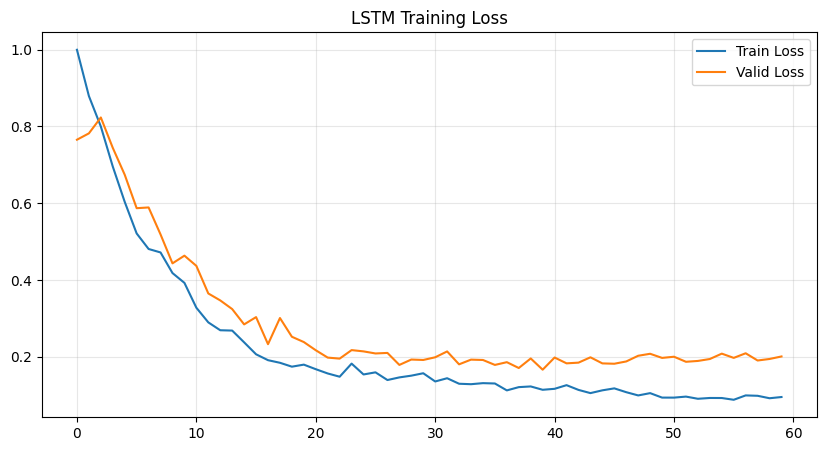

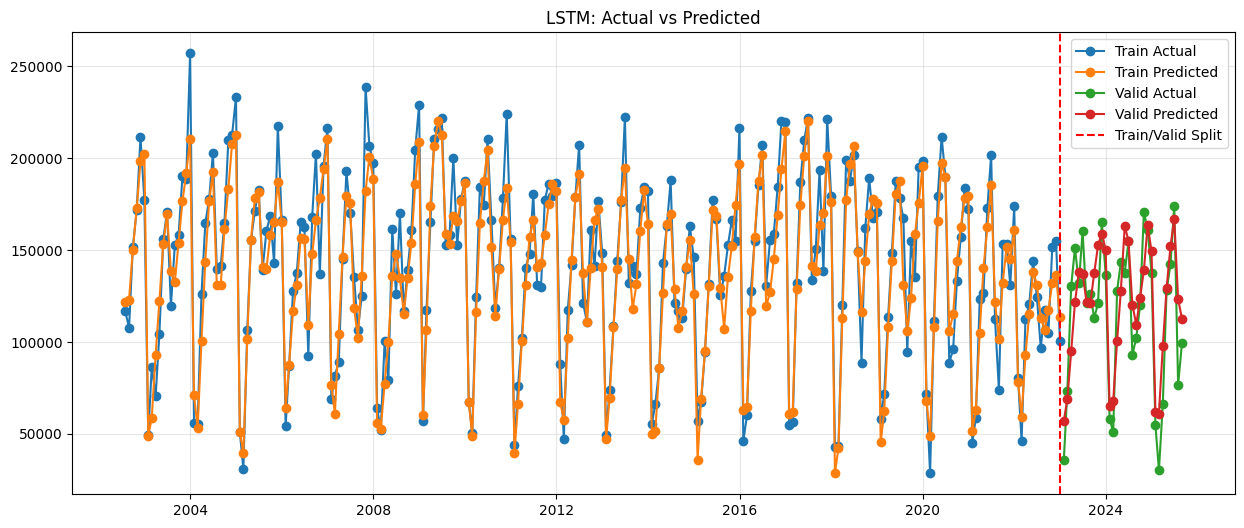

In [10]:
# ===============================================================
# 10. Visualization
# ===============================================================

# Loss Curve
plt.figure(figsize=(10,5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Valid Loss")
plt.title("LSTM Training Loss")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# Actual vs Predicted
plt.figure(figsize=(15,6))
plt.plot(ds_train, y_train_true, "o-", label="Train Actual")
plt.plot(ds_train, train_pred, "o-", label="Train Predicted")

plt.plot(ds_valid, y_valid_true, "o-", label="Valid Actual")
plt.plot(ds_valid, valid_pred, "o-", label="Valid Predicted")

plt.axvline(x=cutoff, color="red", linestyle="--", label="Train/Valid Split")
plt.title("LSTM: Actual vs Predicted")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# 11. Save Model  
학습된 모델을 `.keras` 파일로 저장합니다.

In [11]:
# ===============================================================
# 11. Save Model
# ===============================================================
import os
os.makedirs("../models", exist_ok=True)
model.save(f"../models/lstm_standalone_feature{DATASET_VERSION}.keras")
print("Model saved.")

Model saved.
